# Preprocessing

In [67]:
%load_ext autoreload
%autoreload 2

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CelebA
import torchvision.transforms as T
import torch
from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import dlib
import cv2
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torch.optim import Optimizer
import seaborn as sns
from IPython.display import clear_output
from torch.optim import Adam


openai_imagenet_template = [
    lambda c: f'a bad photo of a {c}.',
    lambda c: f'a photo of many {c}.',
    lambda c: f'a sculpture of a {c}.',
    lambda c: f'a photo of the hard to see {c}.',
    lambda c: f'a low resolution photo of the {c}.',
    lambda c: f'a rendering of a {c}.',
    lambda c: f'graffiti of a {c}.',
    lambda c: f'a bad photo of the {c}.',
    lambda c: f'a cropped photo of the {c}.',
    lambda c: f'a tattoo of a {c}.',
    lambda c: f'the embroidered {c}.',
    lambda c: f'a photo of a hard to see {c}.',
    lambda c: f'a bright photo of a {c}.',
    lambda c: f'a photo of a clean {c}.',
    lambda c: f'a photo of a dirty {c}.',
    lambda c: f'a dark photo of the {c}.',
    lambda c: f'a drawing of a {c}.',
    lambda c: f'a photo of my {c}.',
    lambda c: f'the plastic {c}.',
    lambda c: f'a photo of the cool {c}.',
    lambda c: f'a close-up photo of a {c}.',
    lambda c: f'a black and white photo of the {c}.',
    lambda c: f'a painting of the {c}.',
    lambda c: f'a painting of a {c}.',
    lambda c: f'a pixelated photo of the {c}.',
    lambda c: f'a sculpture of the {c}.',
    lambda c: f'a bright photo of the {c}.',
    lambda c: f'a cropped photo of a {c}.',
    lambda c: f'a plastic {c}.',
    lambda c: f'a photo of the dirty {c}.',
    lambda c: f'a jpeg corrupted photo of a {c}.',
    lambda c: f'a blurry photo of the {c}.',
    lambda c: f'a photo of the {c}.',
    lambda c: f'a good photo of the {c}.',
    lambda c: f'a rendering of the {c}.',
    lambda c: f'a {c} in a video game.',
    lambda c: f'a photo of one {c}.',
    lambda c: f'a doodle of a {c}.',
    lambda c: f'a close-up photo of the {c}.',
    lambda c: f'a photo of a {c}.',
    lambda c: f'the origami {c}.',
    lambda c: f'the {c} in a video game.',
    lambda c: f'a sketch of a {c}.',
    lambda c: f'a doodle of the {c}.',
    lambda c: f'a origami {c}.',
    lambda c: f'a low resolution photo of a {c}.',
    lambda c: f'the toy {c}.',
    lambda c: f'a rendition of the {c}.',
    lambda c: f'a photo of the clean {c}.',
    lambda c: f'a photo of a large {c}.',
    lambda c: f'a rendition of a {c}.',
    lambda c: f'a photo of a nice {c}.',
    lambda c: f'a photo of a weird {c}.',
    lambda c: f'a blurry photo of a {c}.',
    lambda c: f'a cartoon {c}.',
    lambda c: f'art of a {c}.',
    lambda c: f'a sketch of the {c}.',
    lambda c: f'a embroidered {c}.',
    lambda c: f'a pixelated photo of a {c}.',
    lambda c: f'itap of the {c}.',
    lambda c: f'a jpeg corrupted photo of the {c}.',
    lambda c: f'a good photo of a {c}.',
    lambda c: f'a plushie {c}.',
    lambda c: f'a photo of the nice {c}.',
    lambda c: f'a photo of the small {c}.',
    lambda c: f'a photo of the weird {c}.',
    lambda c: f'the cartoon {c}.',
    lambda c: f'art of the {c}.',
    lambda c: f'a drawing of the {c}.',
    lambda c: f'a photo of the large {c}.',
    lambda c: f'a black and white photo of a {c}.',
    lambda c: f'the plushie {c}.',
    lambda c: f'a dark photo of a {c}.',
    lambda c: f'itap of a {c}.',
    lambda c: f'graffiti of the {c}.',
    lambda c: f'a toy {c}.',
    lambda c: f'itap of my {c}.',
    lambda c: f'a photo of a cool {c}.',
    lambda c: f'a photo of a small {c}.',
    lambda c: f'a tattoo of the {c}.',
]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
dataset = CelebA('CelebA', 'train', transform=None, download=True)

In [7]:
type(dataset[0][0]), len(dataset[0][1])

(PIL.JpegImagePlugin.JpegImageFile, 40)

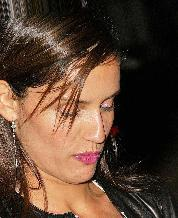

In [16]:
dataset[3][0]

In [18]:
mean = (0.48145466, 0.4578275, 0.40821073)  # ImageNet stats
std = (0.26862954, 0.26130258, 0.27577711)
transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=mean, std=std)
    ]
)

Don't forget - usually bottleneck in your CV pipeline - image reading!

When training from scratch or fine-tuning on your own large diverse dataset - better to recalculate mean and std.

In [21]:
dataset = CelebA('CelebA', 'train', transform=T.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, pin_memory=False, num_workers=2)


running_mean = torch.zeros(3)
total_images = 0

for images, _ in tqdm(dataloader):
    batch_size = images.size(0)
    batch_mean = images.mean(dim=[0, 2, 3])
    running_mean = (running_mean * total_images + batch_mean * batch_size) / (total_images + batch_size)
    total_images += batch_size

print("Mean of each channel (RGB):", running_mean)

Files already downloaded and verified


  0%|          | 0/2544 [00:00<?, ?it/s]

Mean of each channel (RGB): tensor([0.5063, 0.4258, 0.3832])


https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html#sphx-glr-auto-examples-transforms-plot-transforms-illustrations-py

# CLIP

https://arxiv.org/abs/2103.00020

https://github.com/mlfoundations/open_clip

In [23]:
!pip install -q open_clip_torch

In [25]:
import open_clip
open_clip.list_pretrained()

In [26]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-16', pretrained='openai')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/open_clip/factory.py:372: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


In [27]:
preprocess  # super defualt preprocessing

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x7c8d42b09240>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

In [ ]:
zeroshot_weights = []
class_labels = ['cat', 'frog', 'human', ...]
tokenizer = open_clip.get_tokenizer('ViT-B-16')
device = 'cpu'

with torch.inference_mode():
    for classname in tqdm(class_labels):
        texts = []
        for template in openai_imagenet_template:
            texts.append(template(classname))

        tokenized_texts = tokenizer(texts).to(device)
        text_embeddings = model.encode_text(tokenized_texts)

        text_embeddings /= text_embeddings.norm(dim=-1, keepdim=True)
        mean_embedding = text_embeddings.mean(dim=0, keepdim=True)
        mean_embedding /= mean_embedding.norm(dim=-1, keepdim=True)

        zeroshot_weights.append(mean_embedding)

zeroshot_weights = torch.cat(zeroshot_weights, dim=0)

In [ ]:
class CLIP_classification(nn.Module):
    def __init__(self, clip_model, classes_num, weights=None, normalize=False):
        super(CLIP_classification, self).__init__()
        self.clip_model = clip_model
        self.classification_head = nn.Linear(512, classes_num)
        self.normalize = normalize
        if weights is not None:
            self.classification_head.weight = nn.Parameter(weights.clone())
            self.classification_head.bias = nn.Parameter(torch.zeros_like(self.classification_head.bias))

    def forward(self, x):
        x = self.clip_model.encode_image(x)
        if self.normalize:
            x = x / x.norm(dim=-1, keepdim=True)
        return self.classification_head(x)

In [28]:
!wget https://img.freepik.com/premium-photo/full-growthportrait-confident-young-manisolated-white-background_252847-13487.jpg -O human.jpg

--2024-11-14 20:20:03--  https://img.freepik.com/premium-photo/full-growthportrait-confident-young-manisolated-white-background_252847-13487.jpg
Resolving img.freepik.com (img.freepik.com)... 184.28.235.179, 184.28.235.187, 2600:1417:3f::173b:50ba, ...
Connecting to img.freepik.com (img.freepik.com)|184.28.235.179|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24266 (24K) [image/jpeg]
Saving to: ‘human.jpg’

human.jpg           100%[===================>]  23.70K   136KB/s    in 0.2s    

2024-11-14 20:20:05 (136 KB/s) - ‘human.jpg’ saved [24266/24266]



(372, 626)
(224, 376)
(224, 224)


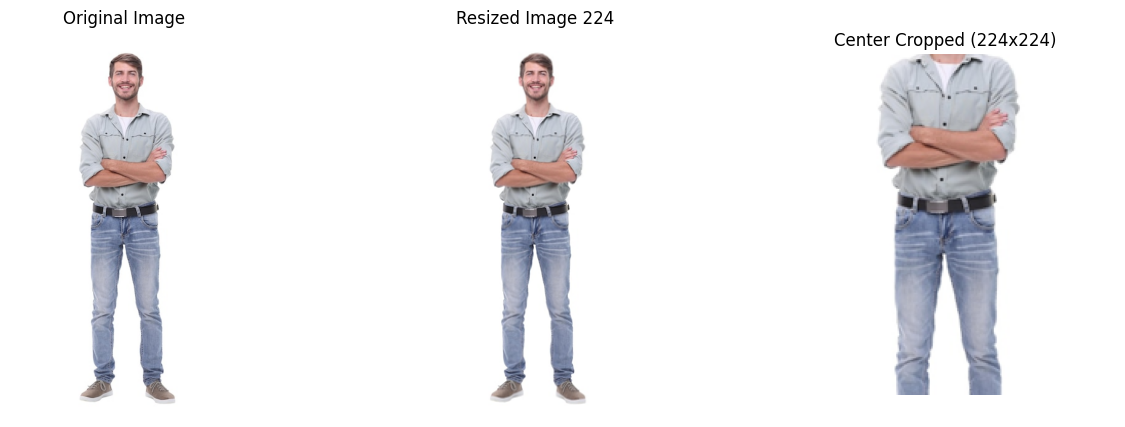

In [35]:
image_path = "human.jpg"
original_image = Image.open(image_path)
resized_image = preprocess.transforms[0](original_image)
center_cropped_image = preprocess.transforms[1](resized_image)
print(original_image.size)
print(resized_image.size)
print(center_cropped_image.size)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(resized_image)
axes[1].set_title("Resized Image 224")
axes[1].axis("off")

axes[2].imshow(center_cropped_image)
axes[2].set_title("Center Cropped (224x224)")
axes[2].axis("off")

plt.show()

# Face Crop

https://github.com/ipazc/mtcnn

https://github.com/deepinsight/insightface

In [46]:
!ls CelebA/celeba/img_align_celeba/025267.jpg

CelebA/celeba/img_align_celeba/025267.jpg


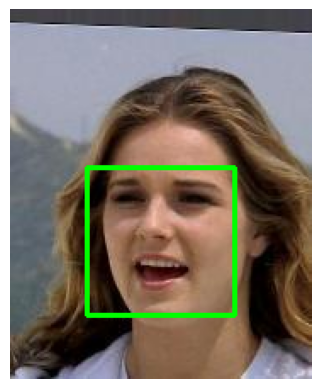

In [47]:
image_path = "CelebA/celeba/img_align_celeba/025267.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

detector = dlib.get_frontal_face_detector()
faces = detector(image_rgb)

for face in faces:
    x, y, w, h = face.left(), face.top(), face.width(), face.height()
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

It's also usually important to align faces. This is not the best example:

https://pyimagesearch.com/2017/05/22/face-alignment-with-opencv-and-python/

And here is a good code:

https://github.com/deepinsight/insightface/blob/master/python-package/insightface/utils/face_align.py

# Cifar classification

In [51]:
dataset_train = CIFAR10('cifar', train=True, download=True)
dataset_train.class_to_idx

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Extracting cifar/cifar-10-python.tar.gz to cifar


{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

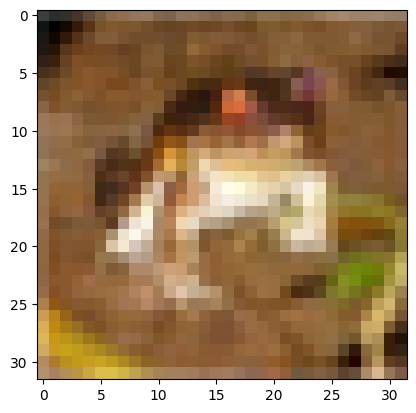

In [53]:
plt.imshow(dataset_train[0][0]);

In [55]:
dataset_train = CIFAR10('cifar', train=True, transform=T.ToTensor())
dataset_train.data.shape

(50000, 32, 32, 3)

In [58]:
mean = (dataset_train.data / 255).mean(axis=(0, 1, 2))
mean

array([0.49139968, 0.48215841, 0.44653091])

In [59]:
std = (dataset_train.data / 255).std(axis=(0, 1, 2))
std

array([0.24703223, 0.24348513, 0.26158784])

In [61]:
transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=mean, std=std)
    ]
)
train_dataset = CIFAR10('cifar', train=True, transform=transforms)
valid_dataset = CIFAR10('cifar', train=False, transform=transforms)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

In [64]:
def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        torch.save(model.state_dict(), f"checkpoints/model_{epoch}.pt")
        torch.save(optimizer.state_dict(), f"checkpoints/optimizer_{epoch}.pt")

In [66]:
class FirstModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # 32 x 32 x 16
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 x 16 x 16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),  # 16 x 16 x 32
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8 x 8 x 32

            nn.Flatten(),

            nn.Linear(8 * 8 * 32, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

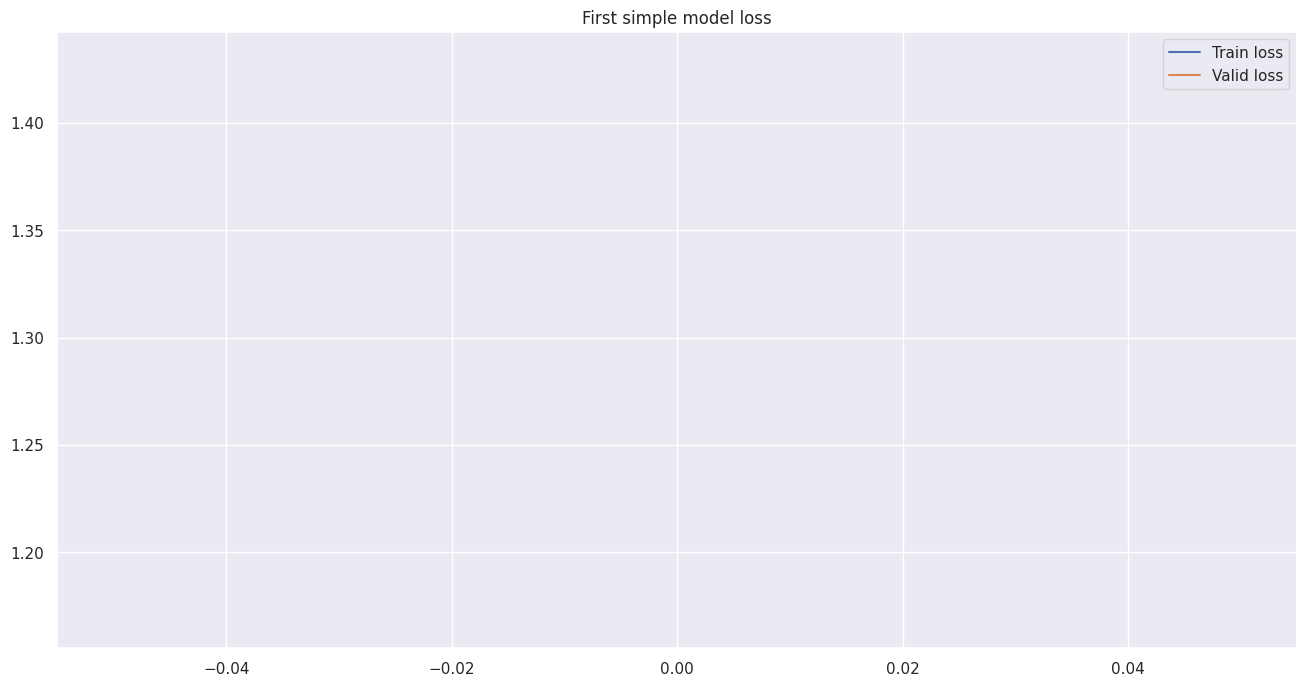

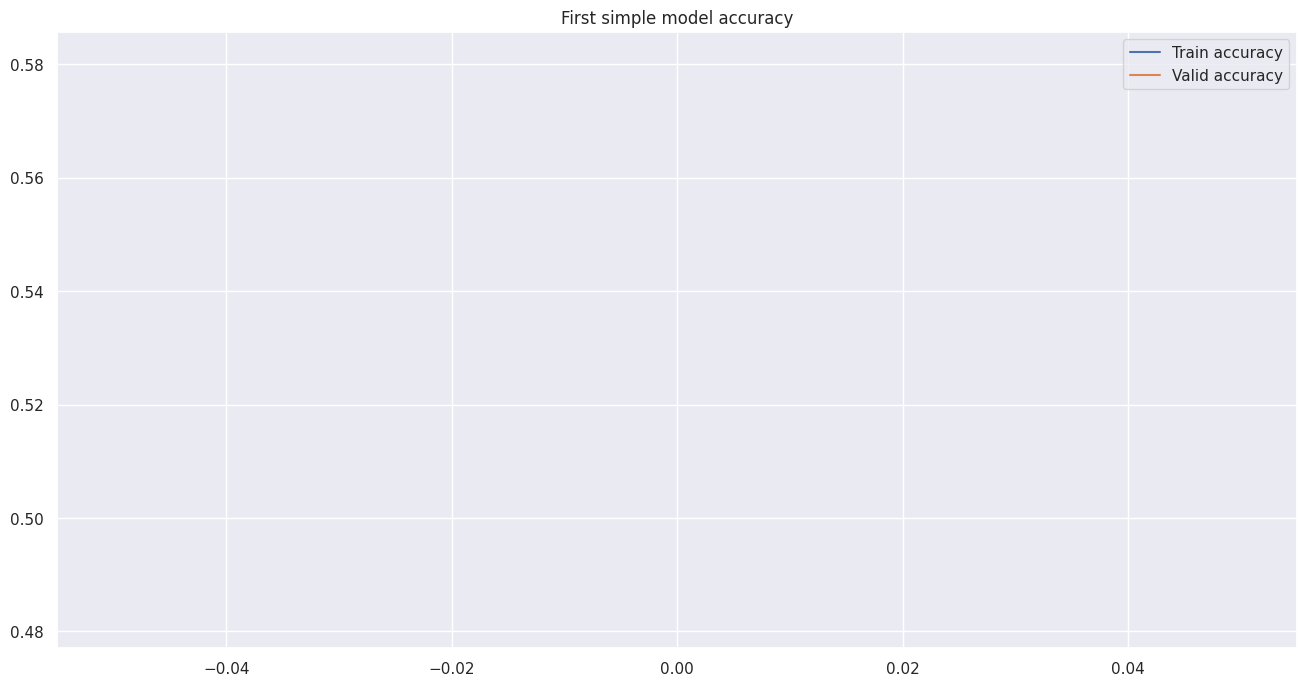

RuntimeError: Parent directory checkpoints does not exist.

In [68]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = FirstModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'First simple model')